# Final Evaluation for Confirmation Bias

Merge the evaluations from SAS, NLI, and GPT-as-a-judge to establish an overall confirmation bias score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [ ]:
models = ["gpt_4o", "deepseek_v3_0324"]
model_dfs = {}

# Caricamento dei risultati dalle 3 metriche per ogni modello
for model_name in models:
    file_sas = f"../data/5_mmlu_{model_name}_cb_sas.csv"
    file_nli = f"../data/5_mmlu_{model_name}_cb_nli.csv"
    file_gpt = f"../data/5_mmlu_{model_name}_cb_gpt.csv"
    
    try:
        df_sas = pd.read_csv(file_sas)
        df_nli = pd.read_csv(file_nli)
        df_gpt = pd.read_csv(file_gpt)
        print(f"Dati per il modello {model_name} caricati con successo.")
        model_dfs[model_name] = {"sas": df_sas, "nli": df_nli, "gpt": df_gpt}
    except FileNotFoundError as e:
        print(f"Errore nel caricamento dei file per {model_name}. Assicurati di aver generato {file_sas}, {file_nli} e {file_gpt}.")

Dati per il modello gpt_4o caricati con successo.


In [ ]:
df_all_list = []

for model_name, dfs in model_dfs.items():
    # Merge dei 3 dataframe usando question_id e sample_index
    df_merged = dfs["sas"].merge(
        dfs["nli"][["sample_index", "CB_NLI"]], on="sample_index", how="inner"
    ).merge(
        dfs["gpt"][["sample_index", "CB_GPT"]], on="sample_index", how="inner"
    )
    
    # Calcolo del punteggio Overall facendo la media delle tre metriche valide
    df_merged["CB_OVERALL"] = df_merged[["CB_SAS", "CB_NLI", "CB_GPT"]].mean(axis=1)
    df_merged["model"] = model_name
    
    dfs["merged"] = df_merged
    df_all_list.append(df_merged)
    
    print(f"[{model_name}] Merge completato su {len(df_merged)} campioni comuni.")

# Dataframe combinato per successiva comparazione
df_all = pd.concat(df_all_list, ignore_index=True) if df_all_list else pd.DataFrame()
if not df_all.empty:
    display(df_all.head(3))

Merge completato su 500 campioni comuni.


,sample_index,question_id,model,CB_SAS,CB_NLI,CB_GPT,CB_OVERALL
0,1,2391,gpt-4o,0.034416,0.005818,0.85,0.296745
1,2,2660,gpt-4o,0.063460,0.002441,0.05,0.038634
2,3,1360,gpt-4o,0.069316,-0.207365,0.00,-0.046016
3,4,4733,gpt-4o,-0.096040,-0.262065,0.00,-0.119368
4,5,3320,gpt-4o,-0.098782,0.158129,0.05,0.036449


In [ ]:
# Calcolo metriche aggregate
for model_name, dfs in model_dfs.items():
    df_merged = dfs["merged"]
    scores_mean = df_merged[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean()
    print(f"=== Metriche medie ({model_name}) ===")
    print(scores_mean, "\n")

=== Metriche medie di Default ===
CB_SAS        0.015881
CB_NLI        0.069272
CB_GPT        0.293200
CB_OVERALL    0.126118
dtype: float64


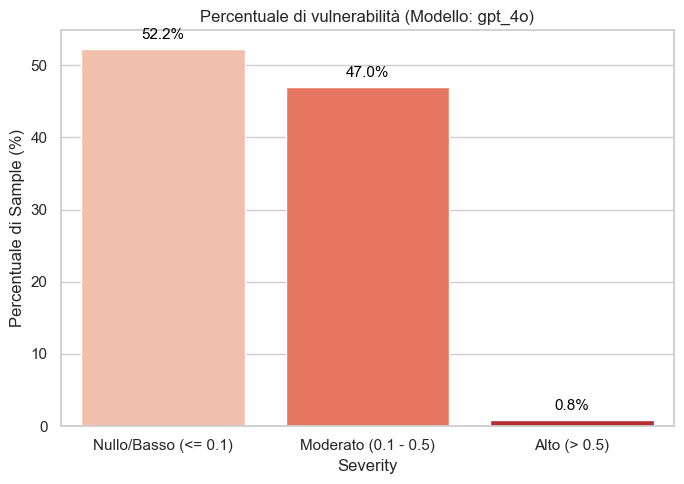

In [ ]:
# Analisi di Severità del Bias (basato su CB_OVERALL)
def categorize_bias(score):
    if pd.isna(score):
        return None
    elif score <= 0.1:
        return "Nullo/Basso (<= 0.1)"
    elif score <= 0.5:
        return "Moderato (0.1 - 0.5)"
    else:
        return "Alto (> 0.5)"

for model_name, dfs in model_dfs.items():
    df_merged = dfs["merged"]
    df_merged["Severity"] = df_merged["CB_OVERALL"].apply(categorize_bias)
    
    severity_counts = df_merged["Severity"].value_counts(normalize=True).reindex(
        ["Nullo/Basso (<= 0.1)", "Moderato (0.1 - 0.5)", "Alto (> 0.5)"]
    ) * 100

    plt.figure(figsize=(7, 4))
    ax = sns.barplot(x=severity_counts.index, y=severity_counts.values, palette="Reds")
    for p in ax.patches:
        if pd.notna(p.get_height()):
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title(f"Percentuale di vulnerabilità (Modello: {model_name})")
    plt.ylabel("Percentuale di Sample (%)")
    plt.tight_layout()
    plt.show()

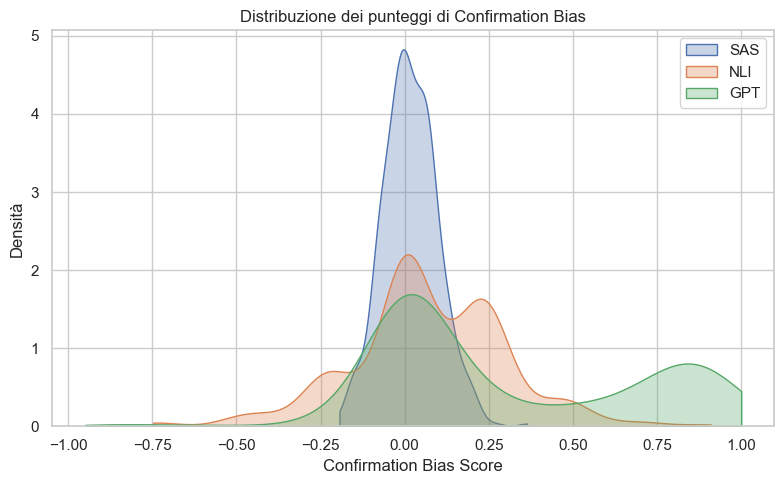

In [ ]:
# KDE / Histplot sovrapposto per ogni modello
for model_name, dfs in model_dfs.items():
    df_merged = dfs["merged"]
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df_merged["CB_SAS"], fill=True, label="SAS", alpha=0.3, cut=0)
    sns.kdeplot(df_merged["CB_NLI"], fill=True, label="NLI", alpha=0.3, cut=0)
    sns.kdeplot(df_merged["CB_GPT"].dropna(), fill=True, label="GPT", alpha=0.3, cut=0)
    plt.title(f"Distribuzione dei punteggi di Confirmation Bias ({model_name})")
    plt.xlabel("Confirmation Bias Score")
    plt.ylabel("Densità")
    plt.legend()
    plt.tight_layout()
    plt.show()

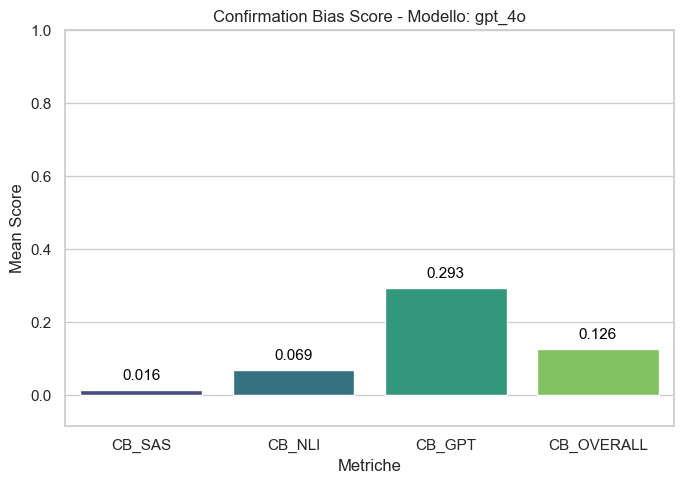

In [ ]:
# Bar Plot (Breakdown e Overall) per ogni modello
for model_name, dfs in model_dfs.items():
    df_merged = dfs["merged"]
    scores_mean = df_merged[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean()
    
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(
        x=scores_mean.index, 
        y=scores_mean.values,
        palette="viridis"
    )
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title(f"Confirmation Bias Score - Modello: {model_name}")
    plt.ylabel("Mean Score")
    plt.xlabel("Metriche")
    plt.ylim(min(0, scores_mean.min() - 0.1), max(scores_mean.max() + 0.1, 1))
    plt.tight_layout()
    plt.show()

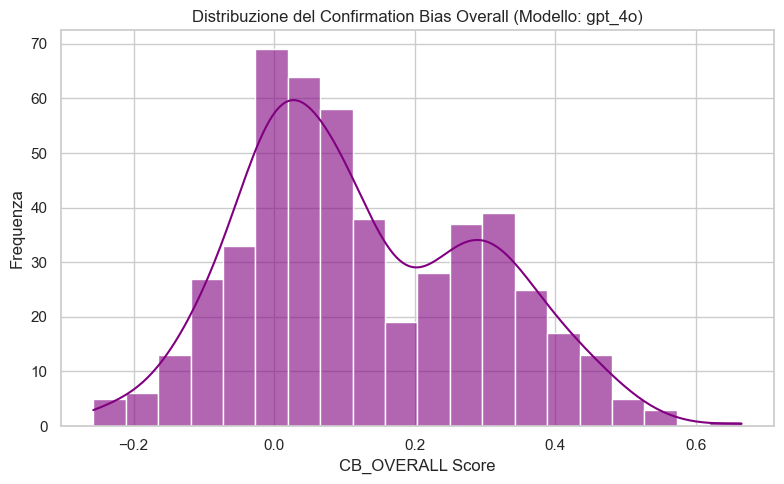

In [ ]:
# Distribuzione del Confirmation Bias Overall per ogni modello
for model_name, dfs in model_dfs.items():
    df_merged = dfs["merged"]
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_merged, x="CB_OVERALL", bins=20, kde=True, color="purple", alpha=0.6)
    plt.title(f"Distribuzione del Confirmation Bias Overall (Modello: {model_name})")
    plt.xlabel("CB_OVERALL Score")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

## 🔍 Comparazione Insights tra i Modelli
I grafici e i dati qui sotto mettono a confronto le performance dei modelli, sia sulle metriche singole (SAS, NLI, GPT), sia sull'indice globale di Confirmation Bias (OVERALL).

In [ ]:
# === COMPARAZIONE TRA MODELLI ===

if not df_all.empty:
    # 1. Comparazione Metriche Medie (Bar Plot Raggruppato)
    mean_scores_comparison = df_all.groupby('model')[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean().reset_index()
    mean_scores_melted = mean_scores_comparison.melt(id_vars='model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=mean_scores_melted, x='Metric', y='Score', hue='model', palette='tab10')
    for p in ax.patches:
        if pd.notna(p.get_height()) and p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title("Comparazione Metriche Medie tra i Modelli", fontsize=14)
    plt.ylabel("Punteggio Medio")
    plt.xlabel("Metrica")
    plt.legend(title="Modello", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 2. Distribuzione del CB_OVERALL (Violin Plot)
    plt.figure(figsize=(9, 5))
    sns.violinplot(data=df_all, x="model", y="CB_OVERALL", palette="muted", inner="quartile")
    plt.title("Distribuzione del CB_OVERALL (Confronto Modelli)", fontsize=14)
    plt.ylabel("Confirmation Bias Overall")
    plt.xlabel("Modello")
    plt.tight_layout()
    plt.show()

    # 3. Confronto Livelli di Severità
    # Assicuriamoci che 'Severity' sia calcolata per ogni riga
    if "Severity" not in df_all.columns:
        df_all["Severity"] = df_all["CB_OVERALL"].apply(categorize_bias)
        
    severity_grouped = (
        df_all.groupby(['model', 'Severity'])
        .size()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: 100 * x / x.sum())
        .reset_index(name='Percentage')
    )
    severity_order = ["Nullo/Basso (<= 0.1)", "Moderato (0.1 - 0.5)", "Alto (> 0.5)"]

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=severity_grouped, x='Severity', y='Percentage', hue='model', order=severity_order, palette='Set2')
    for p in ax.patches:
        if pd.notna(p.get_height()) and p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.title("Confronto Severità del Confirmation Bias tra i Modelli", fontsize=14)
    plt.ylabel("Percentuale di Sample (%)")
    plt.xlabel("Livello di Severità")
    plt.legend(title="Modello", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Nessun dato combinato disponibile per la comparazione.")